# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [2]:
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from cffi.ffiplatform import flatten
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models.video.mvit import PositionalEncoding

In [3]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    # patches = torch.Tensor()
    # number = x.size(dim=1) // patch_size
    # z = 0
    # for i in range(number):
    #     rowstart = z
    #     rowend = z+patch_size
    #     y = 0
    #     for i in range(number):
    #         colstart = y
    #         colend = y+patch_size
    #         patches = torch.stack(patches, x[rowstart:rowend,colstart:colend])
    #         y += patch_size
    #     z += patch_size
    #return patches

    B, C, H, W = x.shape
    P = patch_size
    x = x.reshape(B, C, H // P, P, W // P, P)
    x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
    x = x.reshape(B, (H // P) * (W // P), C * P * P)

    return x


In [4]:
# TODO: Add positional encoding as done in the ViT paper and patch projection
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        self.embeddinglayer = nn.Linear(patch_dim, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        x= self.embeddinglayer(x_patches)
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        return torch.cat((cls_tokens, x), dim=1)


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        self.pos = nn.Parameter(torch.randn(1, num_tokens+1, d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos

In [5]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.
class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


class GLUFeedForward(nn.Module):
    """GLU-family FFN"""
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()

        activations = {
            "GLU": nn.Sigmoid(),
            "SwiGLU": nn.SiLU(),
            "GeGLU": nn.GELU(),
            "Bilinear": nn.Identity()
        }

        self.activation = activations[variant]

        self.model1 = nn.Sequential(
            nn.Linear(d_model, d_ff_gated, bias=False),
            self.activation,
            # nn.Dropout(dropout)
        )
        self.model2 = nn.Sequential(
            nn.Linear(d_model, d_ff_gated, bias=False),
            # nn.Dropout(dropout)
        )
        self.modelcomb = nn.Sequential(
            nn.Linear(d_ff_gated, d_model, bias=False),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        newvec = self.model1(x) * self.model2(x)
        return self.modelcomb(newvec)


In [6]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        # TODO: implement. For attention use nn.MultiHeadAttention
        self.pre_ln = nn.LayerNorm(d_model)
        # self.key = nn.Linear(d_model, d_model, bias=False)
        # self.query = nn.Linear(d_model, d_model, bias=False)
        # self.value = nn.Linear(d_model, d_model, bias=False)
        self.attentionmodule = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.MLPmodule = nn.Sequential(
            nn.LayerNorm(d_model),
            mlp,
            # nn.Dropout(dropout),
        )
        self.dropout = nn.Dropout(dropout)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        pre = self.pre_ln(x)
        attn_output, attn_output_weights = self.attentionmodule(pre, pre, pre)
        attn_output = self.dropout(attn_output) + x
        return attn_output + self.MLPmodule((attn_output))

In [7]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size
        d_ff_gated = int(d_ff *(2/3))

        # def what_mpl:
        #     if mlp_kind == "FNN":
        #         return FeedForward(d_model, d_ff, dropout)
        #     else:
        #         return GLUFeedForward( d_model, d_ff_gated, dropout, mlp_kind)

        # TODO: implement a strategy for embedding the patches
        self.embedding = PatchEmbed(patch_dim, d_model)
        self.posembed = PositionalEmbedding(self.num_tokens, d_model)


        # TODO: implement a strategy to select the right mlp version for your experime
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp= (FeedForward(d_model, d_ff, dropout) if mlp_kind == "FNN"
                      else GLUFeedForward(d_model, d_ff_gated, dropout, mlp_kind)), # TODO: Feed your mlp to the encoder blocks
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        # TODO: Add a head to project to the amount of output classes you have
        self.head = nn.Linear(d_model, 10) # 10 number of classes
        se

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        patch = patchify(x, self.patch_size)
        posembedding = self.posembed(self.embedding(patch))
        for block in self.blocks:
            posembedding = block(posembedding)
        cls_token = posembedding[:, 0]
        logits = self.head(cls_token)
        return logits


In [8]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "mps"  # set "cuda" if available was cpu before


In [9]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    test_accs: list[float] = []

    for epoch in range(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            loss = torch.nn.functional.cross_entropy(logits, yb) # TODO: Your criterion

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    return {
        "mlp_kind": mlp_kind,
        "train_losses": train_losses,  # For convergence speed plot
        "test_accs": test_accs,        # For accuracy vs epochs plot
        "best_acc": max(test_accs),    # "Best" accuracy deliverable
        "final_acc": test_accs[-1],    # "Final" accuracy deliverable
        "params": sum(p.numel() for p in model.parameters() if p.requires_grad)
    }

In [10]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="mps")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_size = 14
d_model = 64
n_heads = 4
n_layers = 3
d_ff = 256
dropout = 0.1

runs = ["FNN", "GLU", "GeGLU", "SwiGLU"] # TODO: Name your runs
results = []

seeds = [0, 42, 2026]
all_results = {}
for kind in runs:
    kind_seeds = []
    for seed in seeds:
        # Set seed for reproducibility
        torch.manual_seed(seed)
        model = TinyViT(
            patch_size=patch_size,
            d_model=d_model,
            n_heads=n_heads,
            n_layers=n_layers,
            d_ff=d_ff,
            dropout=dropout,
            mlp_kind=kind,
        )
        # TODO: print anything you might want here
        print(f"\nRun: {kind} | " )
        total_params = sum(p.numel() for p in model.parameters())
        print(f"\nRun: {kind} | Parameters: {total_params:,}")
        out = train_one_run(kind, model, train_loader, test_loader, cfg)
        results.append(out)
        kind_seeds.append(out)


    all_results[kind] = kind_seeds


Run: FNN | 

Run: FNN | Parameters: 163,594
[FNN] epoch 1/5 | test acc: 0.9322
[FNN] epoch 2/5 | test acc: 0.9507
[FNN] epoch 3/5 | test acc: 0.9588
[FNN] epoch 4/5 | test acc: 0.9641
[FNN] epoch 5/5 | test acc: 0.9721

Run: FNN | 

Run: FNN | Parameters: 163,594
[FNN] epoch 1/5 | test acc: 0.9318
[FNN] epoch 2/5 | test acc: 0.9539
[FNN] epoch 3/5 | test acc: 0.9627
[FNN] epoch 4/5 | test acc: 0.9663
[FNN] epoch 5/5 | test acc: 0.9696

Run: FNN | 

Run: FNN | Parameters: 163,594
[FNN] epoch 1/5 | test acc: 0.9208
[FNN] epoch 2/5 | test acc: 0.9523
[FNN] epoch 3/5 | test acc: 0.9578
[FNN] epoch 4/5 | test acc: 0.9669
[FNN] epoch 5/5 | test acc: 0.9665

Run: GLU | 

Run: GLU | Parameters: 162,250
[GLU] epoch 1/5 | test acc: 0.9206
[GLU] epoch 2/5 | test acc: 0.9486
[GLU] epoch 3/5 | test acc: 0.9614
[GLU] epoch 4/5 | test acc: 0.9621
[GLU] epoch 5/5 | test acc: 0.9684

Run: GLU | 

Run: GLU | Parameters: 162,250
[GLU] epoch 1/5 | test acc: 0.9269
[GLU] epoch 2/5 | test acc: 0.9536
[GLU]

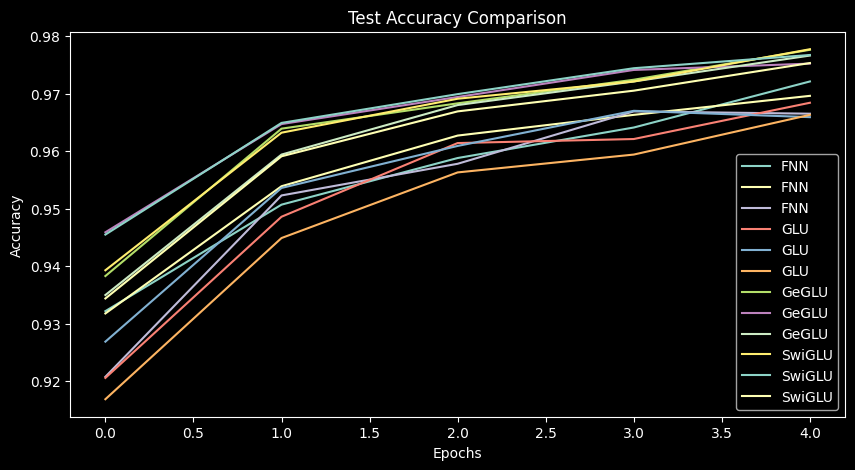

Method     | Params     | Best Acc (Mean ± Std) |  Final Acc (Mean ± Std) | Stability
------------------------------------------------------------
FNN        | 163594     | Best: 0.9695 ± 0.0021 | Final: 0.9694±0.0023 | High
GLU        | 162250     | Best: 0.9672 ± 0.0009 | Final: 0.9669±0.0011 | High
GeGLU      | 162250     | Best: 0.9765 ± 0.0010 | Final: 0.9765±0.0010 | High
SwiGLU     | 162250     | Best: 0.9766 ± 0.0010 | Final: 0.9766±0.0010 | High


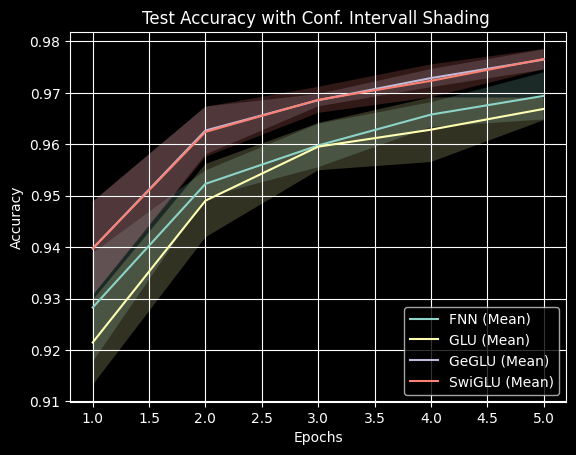

<Figure size 1000x600 with 0 Axes>

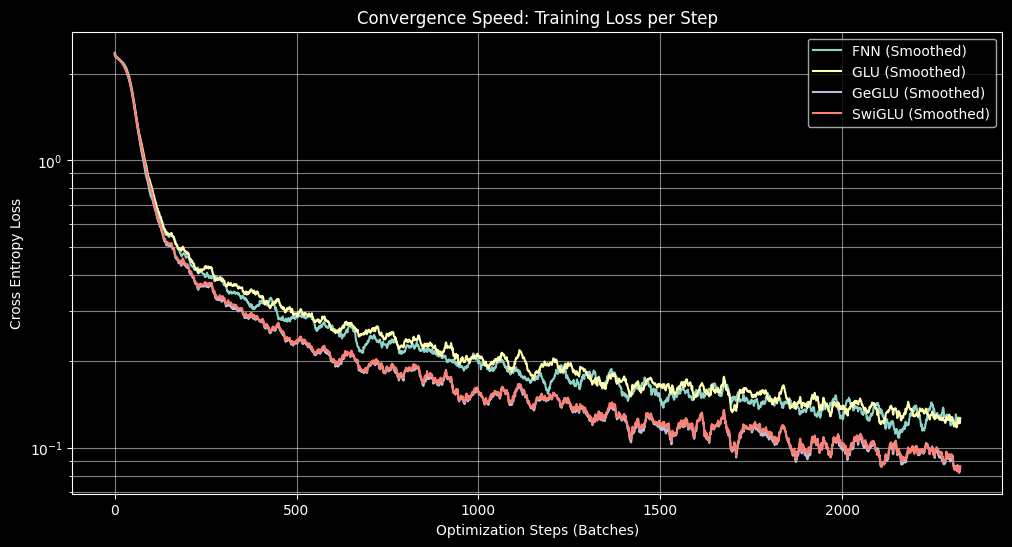

In [17]:
# import matplotlib.pyplot as plt
#
# plt.figure(figsize=(10, 5))
# for result in results:
#     plt.plot(result["test_accs"], label=result["mlp_kind"])
# plt.title("Test Accuracy Comparison")
# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.show()
#
# import numpy as np
#
# print(f"{'Method':<10} | {'Params':<10} | {'Best Acc (Mean ± Std)':<20} |  {'Final Acc (Mean ± Std)':<20} | {'Stability'}")
# print("-" * 60)
#
# for kind, runs_data in all_results.items():
#     best_accs = [r["best_acc"] for r in runs_data]
#     mean_acc = np.mean(best_accs)
#     std_acc = np.std(best_accs)
#     params = runs_data[0]["params"]
#     final_accs = [r["test_accs"][-1] for r in runs_data]
#     mean_final = np.mean(final_accs)
#     std_final = np.std(final_accs)
#
#
#     # Stability is inversely proportional to Std Dev
#     stability = "High" if std_acc < 0.005 else "Low"
#
#     print(f"{kind:<10} | {params:<10} | Best: {mean_acc:.4f} ± {std_acc:.4f} | Final: {mean_final:.4f}±{std_final:.4f} | {stability}")
#
#     acc_matrix = np.array([r["test_accs"] for r in runs_data])
#     mean_accs = acc_matrix.mean(axis=0)
#     std_accs = acc_matrix.std(axis=0)
#
#     epochs = range(1, cfg.epochs + 1)
#     plt.plot(epochs, mean_accs, label=f"{kind} (Mean)")
#     plt.fill_between(epochs, mean_accs - 2*std_accs, mean_accs + 2*std_accs, alpha=0.2)
#
# plt.title("Test Accuracy with Conf. Intervall Shading ")
# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.grid(True)
# plt.show()
#
# plt.figure(figsize=(10, 6))
#
# def plot_convergence(all_results):
#     plt.figure(figsize=(12, 6))
#
#     for kind, runs_data in all_results.items():
#         # runs_data is a list of dicts (one for each seed)
#         # We convert to a 2D array: (number of seeds, total optimization steps)
#         loss_matrix = np.array([r["train_losses"] for r in runs_data])
#
#         # Calculate mean and std across seeds for each step
#         mean_loss = loss_matrix.mean(axis=0)
#         std_loss = loss_matrix.std(axis=0)
#
#         steps = np.arange(len(mean_loss))
#
#         # Plotting the raw mean with low alpha or a smoothed version
#         # Smooth the line for better visibility using a simple moving average
#         window = 20
#         smoothed_mean = np.convolve(mean_loss, np.ones(window)/window, mode='valid')
#         smoothed_steps = steps[:len(smoothed_mean)]
#
#         line, = plt.plot(smoothed_steps, smoothed_mean, label=f"{kind} (Smoothed)")
#
#         # Add variance shading (optional, can look messy on loss plots)
#         #plt.fill_between(steps, mean_loss - 2*std_loss, mean_loss + 2*std_loss, color=line.get_color(), alpha=0.1)
#
#     plt.title("Convergence Speed: Training Loss per Step")
#     plt.xlabel("Optimization Steps (Batches)")
#     plt.ylabel("Cross Entropy Loss")
#     plt.yscale('log') # Log scale helps see differences when loss gets small
#     plt.legend()
#     plt.grid(True, which="both", ls="-", alpha=0.5)
#     plt.show()
#
# # Call this after your training loop finishes
# plot_convergence(all_results)
